In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class LinearRegression:
    def __init__(self):
        self.weight = 0
        self.bias = 0
        self.y_hat = None
        self.Huber_Loss = None
        self.loss = []
    def predict(self, x):
        y = self.weight * x + self.bias
        return y 
    def gradient(self, x, y, D = 1.0):
        n = len(x)
        y_hat = self.predict(x)
        residual = y - y_hat
        grad_res = np.where(np.abs(residual) <= D, residual, D * np.sign(residual))
        gr_w = -(1/n) * np.sum(grad_res * x)
        gr_b = -(1/n) * np.sum(grad_res)

        return gr_w, gr_b
    def fit(self, x, y, learning_rate = 0.001, epochs = 1000, D = 1.0):
        for epoch in range(epochs):
            Loss_ = self.huber_Loss(x, y, D)
            self.loss.append(Loss_)
            gr_w, gr_b = self.gradient(x, y, D)
            self.weight -= learning_rate * gr_w
            self.bias -= learning_rate * gr_b
        self.y_hat = self.predict(x)
        self.Huber_Loss = self.huber_Loss(x, y, D)
    def huber_Loss(self, x, y, D = 1.0):
        y_hat = self.predict(x)
        residual = y - y_hat
        # |r| <= Delta -> 0.5 * r**2, |r| > Delta -> Delta(|r| - 0.5 * Delta)
        Loss = np.where(np.abs(residual) <= D, 0.5 * residual**2, D * (np.abs(residual) - 0.5 * D))
        return np.mean(Loss)



weight :  3.203315175974175
Bias : 3.5360154464381357
huber loss :  <bound method LinearRegression.huber_Loss of <__main__.LinearRegression object at 0x00000237B3FF9850>>


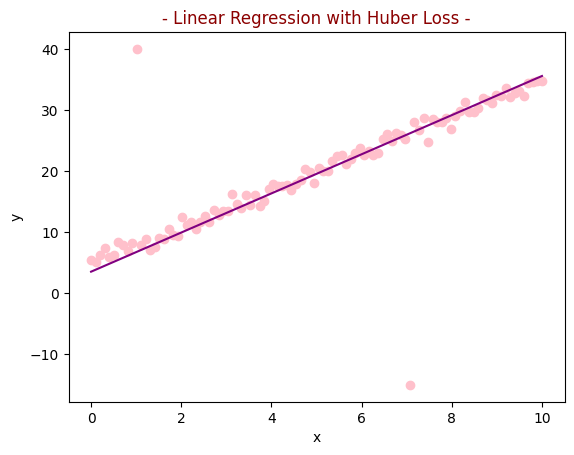

In [13]:
#Here? i just made a dataset by myself :)

np.random.seed(42)
x = np.linspace(0, 10, 100)

y = 3*x + 5 + np.random.normal(0, 1, 100)
y[10] = 40
y[70] = -15
model = LinearRegression()
model.fit(x, y, learning_rate= 0.01, epochs = 1000, D = 1.0)
print("weight : ", model.weight)
print("Bias :", model.bias)
print("huber loss : ", model.huber_Loss)

plt.scatter(x, y, color = "pink")
x_ = np.linspace(x.min(), x.max(), 100)
y_ = model.predict(x_)
plt.plot(x_, y_, color = "purple")
plt.xlabel("x")
plt.ylabel("y")
plt.title("- Linear Regression with Huber Loss -",  color= "darkred")
plt.show()